# Survival Analysis

This notebook was split from the original G'Contest final-round working notebook for faster GitHub review. Raw data and data-loading code are intentionally excluded. Saved outputs are preserved so interviewers can inspect the completed analysis and results without rerunning the private dataset.

**Interview focus:** Uses survival-analysis methods to examine completion/drop-off dynamics across customer and device groups.


# VII. Survival Analysis

In [ ]:
cols = [ 'age', 'status', 'hour_of_day', 'day_of_week', 'is_office_hour', 'is_weekend', 'gender_M', 'phone_OPPO',
       'phone_Others', 'phone_Redmi', 'phone_samsung', 'time_evening', 'time_morning']  # Các cột về đặc điểm khách hàng và bối cảnh thao tác

df_analytical = df_model_combine[cols]

In [ ]:
# Dependency note: lifelines is required for survival analysis in this section.
!pip install lifelines

In [ ]:
# Bắt đầu từ df_cleaned để đảm bảo có đủ các cột gốc
# và df_analytical để lấy danh sách các cột cần thiết
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test
import matplotlib.pyplot as plt

# --- 1. Tạo DataFrame cho phân tích sống còn ---

# Lấy các đặc trưng tĩnh của mỗi khách hàng (lấy thông tin từ lần thử đầu tiên)
# Chúng ta sẽ sử dụng các cột đã được bạn chọn trong df_analytical, nhưng lấy từ df_cleaned và df_model_combine để có đủ thông tin
customer_features = (
    df_model_combine
    .groupby('customer_id')
    .first() # Lấy thông tin từ dòng đầu tiên của mỗi khách hàng
    .reset_index()
)

# Tính Duration (T) và Event (E) cho mỗi khách hàng
survival_data = (
    df_cleaned
    .groupby('customer_id')
    .agg(
        # T: Tổng số lần thử của khách hàng
        T=('begin_time', 'size'),
        # E: Khách hàng có thành công không (1 nếu có, 0 nếu không)
        E=('status', lambda x: 1 if 'succeed' in x.values else 0)
    )
    .reset_index()
)

# Kết hợp lại để có DataFrame hoàn chỉnh
df_survival = pd.merge(survival_data, customer_features, on='customer_id')

# Chọn các cột cuối cùng để phân tích (tương tự df_analytical của bạn)
cols_for_survival = ['T', 'E', 'age', 'is_weekend', 'is_office_hour', 'gender_M', 'phone_OPPO',
                     'phone_Others', 'phone_Redmi', 'phone_samsung', 'time_evening', 'time_morning']

df_survival = df_survival[cols_for_survival]


print("✅ Dữ liệu cho phân tích sống còn đã sẵn sàng:")
display(df_survival.head())
print("\nPhân phối sự kiện (1 = Succeed, 0 = Censored/Fail):")
print(df_survival['E'].value_counts(normalize=True))

✅ Dữ liệu cho phân tích sống còn đã sẵn sàng:


,T,E,age,is_weekend,is_office_hour,gender_M,phone_OPPO,phone_Others,phone_Redmi,phone_samsung,time_evening,time_morning
0,2,1,32.0,0,1,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,8,0,27.0,0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,1,29.0,0,1,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3,2,1,26.0,0,1,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,3,1,33.0,0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0



Phân phối sự kiện (1 = Succeed, 0 = Censored/Fail):
E
1    0.933865
0    0.066135
Name: proportion, dtype: float64


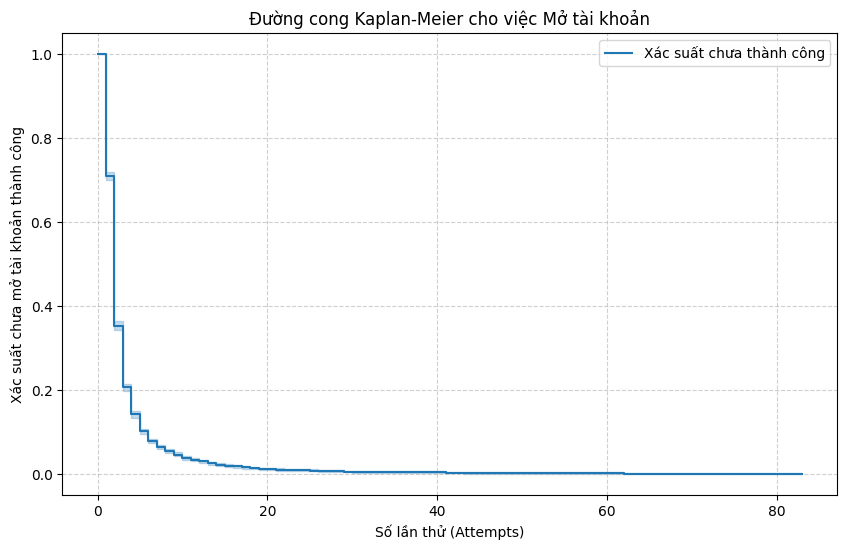

In [ ]:
# --- 2. Phân tích tổng quan với Kaplan-Meier ---

# Khởi tạo mô hình
kmf = KaplanMeierFitter()

# Fit mô hình vào dữ liệu
T = df_survival['T'] # Duration: số lần thử
E = df_survival['E'] # Event: có thành công không
kmf.fit(T, event_observed=E)

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
kmf.plot(label='Xác suất chưa thành công')
plt.title('Đường cong Kaplan-Meier cho việc Mở tài khoản')
plt.xlabel('Số lần thử (Attempts)')
plt.ylabel('Xác suất chưa mở tài khoản thành công')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

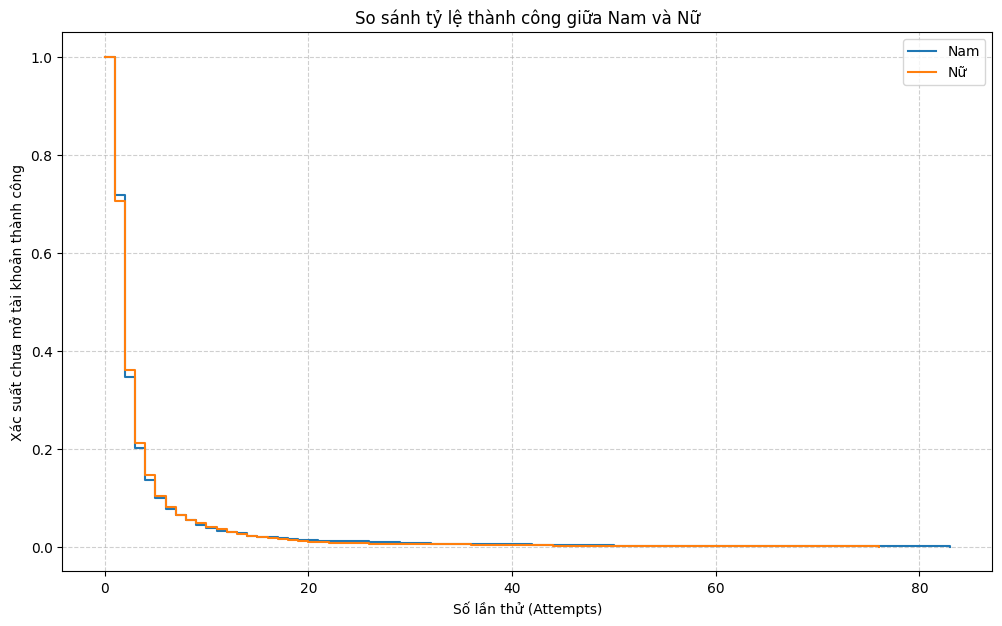


Kết quả kiểm định Log-Rank so sánh Nam và Nữ:


<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic    p  -log2(p)
           0.15 0.70      0.51

In [ ]:
# --- 3. So sánh các nhóm với Kaplan-Meier ---
plt.figure(figsize=(12, 7))
ax = plt.subplot(111)

# Nhóm Nam (gender_M = 1)
male_mask = df_survival['gender_M'] == 1
kmf.fit(T[male_mask], event_observed=E[male_mask], label='Nam')
# Thêm ci_show=False để ẩn vùng mờ (khoảng tin cậy)
kmf.plot_survival_function(ax=ax, ci_show=False) # <-- THÊM THAM SỐ NÀY

# Nhóm Nữ (gender_M = 0)
female_mask = df_survival['gender_M'] == 0
kmf.fit(T[female_mask], event_observed=E[female_mask], label='Nữ')
# Thêm ci_show=False để ẩn vùng mờ (khoảng tin cậy)
kmf.plot_survival_function(ax=ax, ci_show=False) # <-- THÊM THAM SỐ NÀY

plt.title('So sánh tỷ lệ thành công giữa Nam và Nữ')
plt.xlabel('Số lần thử (Attempts)')
plt.ylabel('Xác suất chưa mở tài khoản thành công')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

# --- Phần kiểm định Log-Rank giữ nguyên ---
results = logrank_test(T[male_mask], T[female_mask], event_observed_A=E[male_mask], event_observed_B=E[female_mask])
print("\nKết quả kiểm định Log-Rank so sánh Nam và Nữ:")
results.print_summary()

In [ ]:
# --- 1. TẠO LẠI DataFrame cho phân tích sống còn (thêm cột generation & phone_type) ---

# Lấy các đặc trưng tĩnh của mỗi khách hàng (lấy thông tin từ lần thử đầu tiên)
# Lần này ta sẽ lấy các cột cần thiết từ df_cleaned để có 'generation' và 'phone_type_grouped'
customer_features_updated = (
    df_cleaned  # Sử dụng df_cleaned vì nó chứa các cột bạn đã tạo
    .groupby('customer_id')
    .first() # Lấy thông tin từ dòng đầu tiên của mỗi khách hàng
    .reset_index()
)

# Tính Duration (T) và Event (E) cho mỗi khách hàng (giống như trước)
survival_data = (
    df_cleaned
    .groupby('customer_id')
    .agg(
        T=('begin_time', 'size'),
        E=('status', lambda x: 1 if 'succeed' in x.values else 0)
    )
    .reset_index()
)

# Kết hợp lại để có DataFrame hoàn chỉnh
df_survival_updated = pd.merge(survival_data, customer_features_updated, on='customer_id')

# Chọn các cột cần thiết cho việc so sánh
cols_for_comparison = ['T', 'E', 'generation', 'phone_type_grouped']
df_survival_updated = df_survival_updated[cols_for_comparison]


print("✅ Dữ liệu cho việc so sánh nhóm đã sẵn sàng:")
display(df_survival_updated.head())

✅ Dữ liệu cho việc so sánh nhóm đã sẵn sàng:


,T,E,generation,phone_type_grouped
0,2,1,Gen Y (Millennials),Apple
1,8,0,Gen Z,Apple
2,3,1,Gen Y (Millennials),Redmi
3,2,1,Gen Z,Apple
4,3,1,Gen Y (Millennials),Apple


Bắt đầu so sánh các thế hệ...
Đã vẽ xong cho nhóm: Gen Y (Millennials)
Đã vẽ xong cho nhóm: Gen Z
Đã vẽ xong cho nhóm: Gen X
Đã vẽ xong cho nhóm: Boomers


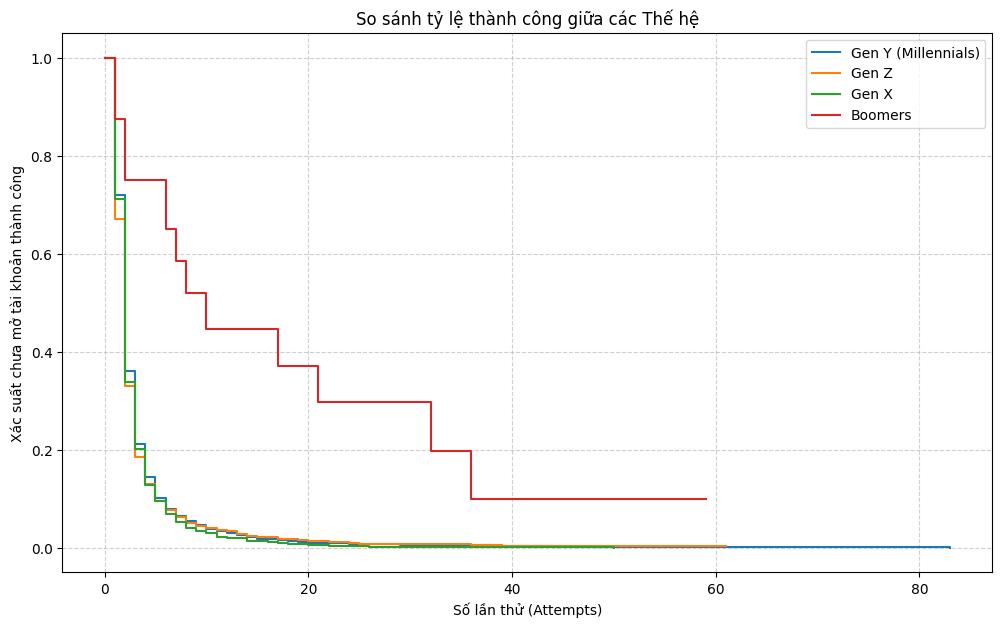


Kết quả kiểm định Log-Rank so sánh các thế hệ:


<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 3
         test_name = multivariate_logrank_test

---
 test_statistic      p  -log2(p)
          47.87 <0.005     32.04

In [ ]:
# --- 2. So sánh các nhóm thế hệ (Gen Z, Gen Y, Gen X, Boomers) ---

# Lấy T và E từ DataFrame mới
T = df_survival_updated['T']
E = df_survival_updated['E']

plt.figure(figsize=(12, 7))
ax = plt.subplot(111)

# Lấy danh sách các thế hệ duy nhất để lặp qua
generations = df_survival_updated['generation'].unique()
generations = [gen for gen in generations if gen != 'Unknown'] # Bỏ qua nhóm 'Unknown' nếu có

print("Bắt đầu so sánh các thế hệ...")

for gen in generations:
    mask = df_survival_updated['generation'] == gen
    kmf.fit(T[mask], event_observed=E[mask], label=gen)
    kmf.plot_survival_function(ax=ax, ci_show=False)
    print(f"Đã vẽ xong cho nhóm: {gen}")


plt.title('So sánh tỷ lệ thành công giữa các Thế hệ')
plt.xlabel('Số lần thử (Attempts)')
plt.ylabel('Xác suất chưa mở tài khoản thành công')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

# --- Kiểm định Log-Rank cho nhiều nhóm ---
# Lưu ý: logrank_test của lifelines chỉ so sánh 2 nhóm.
# Để so sánh nhiều nhóm, ta dùng multivariate_logrank_test
from lifelines.statistics import multivariate_logrank_test

results_gen = multivariate_logrank_test(
    df_survival_updated['T'],
    df_survival_updated['generation'],
    df_survival_updated['E']
)

print("\nKết quả kiểm định Log-Rank so sánh các thế hệ:")
results_gen.print_summary()


Bắt đầu so sánh các loại điện thoại...
Đã vẽ xong cho nhóm: Apple
Đã vẽ xong cho nhóm: Redmi
Đã vẽ xong cho nhóm: OPPO
Đã vẽ xong cho nhóm: Others
Đã vẽ xong cho nhóm: samsung


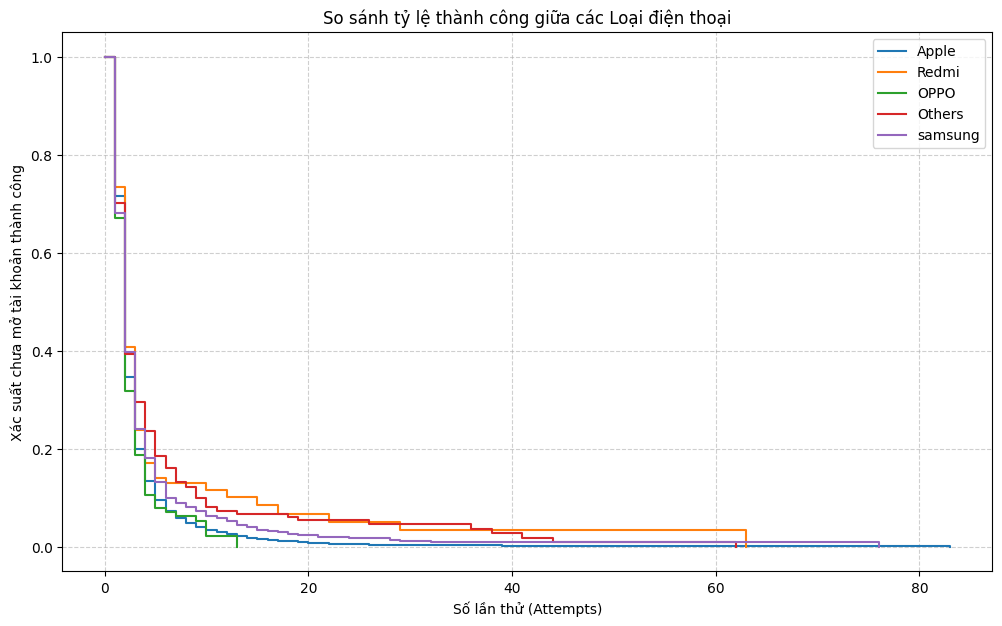


Kết quả kiểm định Log-Rank so sánh các loại điện thoại:


<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 4
         test_name = multivariate_logrank_test

---
 test_statistic      p  -log2(p)
          32.04 <0.005     19.02

In [ ]:
# --- 3. So sánh các nhóm điện thoại (Apple, Samsung, OPPO, ...) ---

plt.figure(figsize=(12, 7))
ax = plt.subplot(111)

# Lấy danh sách các loại điện thoại duy nhất để lặp qua
phone_types = df_survival_updated['phone_type_grouped'].unique()

print("\nBắt đầu so sánh các loại điện thoại...")

for phone in phone_types:
    mask = df_survival_updated['phone_type_grouped'] == phone
    kmf.fit(T[mask], event_observed=E[mask], label=phone)
    kmf.plot_survival_function(ax=ax, ci_show=False)
    print(f"Đã vẽ xong cho nhóm: {phone}")

plt.title('So sánh tỷ lệ thành công giữa các Loại điện thoại')
plt.xlabel('Số lần thử (Attempts)')
plt.ylabel('Xác suất chưa mở tài khoản thành công')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

# --- Kiểm định Log-Rank cho nhiều nhóm điện thoại ---
results_phone = multivariate_logrank_test(
    df_survival_updated['T'],
    df_survival_updated['phone_type_grouped'],
    df_survival_updated['E']
)

print("\nKết quả kiểm định Log-Rank so sánh các loại điện thoại:")
results_phone.print_summary()

In [ ]:
# --- 1. Đảm bảo dữ liệu đã sẵn sàng (ĐÃ SỬA LỖI) ---
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test, logrank_test

# ----- PHẦN SỬA LỖI: TẠO CÁC CỘT CÒN THIẾU TRONG df_cleaned -----
# Trong phần code trước đó, bạn đã tạo 'is_weekend' và 'time_period'
# nhưng là ở trong df_model. Bây giờ ta cần tạo chúng trong df_cleaned.

# Đảm bảo cột 'begin_time' là kiểu datetime
df_cleaned['begin_time'] = pd.to_datetime(df_cleaned['begin_time'])

# TẠO CỘT 'is_weekend'
df_cleaned['day_of_week'] = df_cleaned['begin_time'].dt.dayofweek # Monday=0, Sunday=6
df_cleaned['is_weekend'] = (df_cleaned['day_of_week'] >= 5).astype(int)

# TẠO CỘT 'time_period' (nếu chưa có trong df_cleaned)
def classify_period(hour):
    if 5 <= hour < 12: return 'Morning'
    elif 12 <= hour < 17: return 'Afternoon'
    else: return 'Evening'

if 'time_period' not in df_cleaned.columns:
    df_cleaned['time_period'] = df_cleaned['begin_time'].dt.hour.apply(classify_period)

# ----------------------------------------------------------------

# Lấy các đặc trưng tĩnh của mỗi khách hàng (từ lần thử đầu tiên)
customer_features_full = (
    df_cleaned
    .groupby('customer_id')
    .first()
    .reset_index()
)

# Tính Duration (T) và Event (E)
survival_data = (
    df_cleaned
    .groupby('customer_id')
    .agg(
        T=('begin_time', 'size'),
        E=('status', lambda x: 1 if 'succeed' in x.values else 0)
    )
    .reset_index()
)

# Kết hợp lại để có DataFrame hoàn chỉnh
df_survival_full = pd.merge(survival_data, customer_features_full, on='customer_id')

# Chọn các cột cần thiết cho việc so sánh thời gian
# Bây giờ các cột này đã tồn tại trong df_survival_full
cols_for_time_comparison = ['T', 'E', 'time_period', 'is_weekend']
df_survival_time = df_survival_full[cols_for_time_comparison]

print("✅ Dữ liệu cho việc so sánh nhóm theo thời gian đã sẵn sàng:")
display(df_survival_time.head())

✅ Dữ liệu cho việc so sánh nhóm theo thời gian đã sẵn sàng:


,T,E,time_period,is_weekend
0,2,1,Morning,0
1,8,0,Morning,0
2,3,1,Afternoon,0
3,2,1,Afternoon,0
4,3,1,Afternoon,0


Bắt đầu so sánh các buổi trong ngày...
Đã vẽ xong cho nhóm: Morning
Đã vẽ xong cho nhóm: Afternoon
Đã vẽ xong cho nhóm: Evening


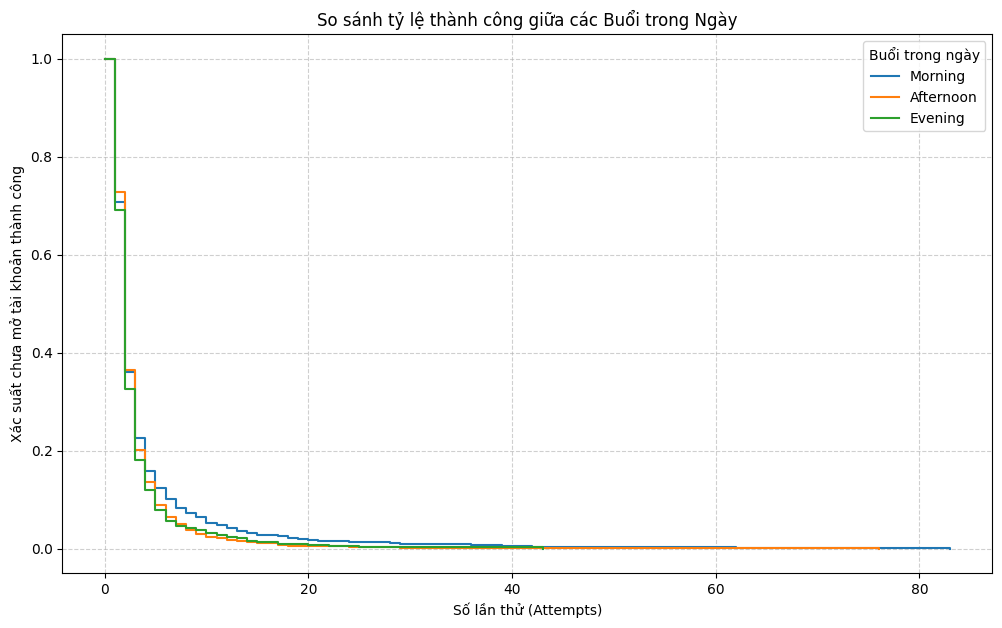


Kết quả kiểm định Log-Rank so sánh các buổi trong ngày:


<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 2
         test_name = multivariate_logrank_test

---
 test_statistic      p  -log2(p)
          24.71 <0.005     17.82

In [ ]:
# --- 2. So sánh các nhóm theo Thời gian trong ngày (Sáng, Chiều, Tối) ---

# Lấy T và E từ DataFrame mới
T = df_survival_time['T']
E = df_survival_time['E']

plt.figure(figsize=(12, 7))
ax = plt.subplot(111)

# Lấy danh sách các buổi trong ngày để lặp qua
time_periods = ['Morning', 'Afternoon', 'Evening'] # Sắp xếp theo thứ tự logic

print("Bắt đầu so sánh các buổi trong ngày...")

for period in time_periods:
    mask = df_survival_time['time_period'] == period
    kmf.fit(T[mask], event_observed=E[mask], label=period)
    kmf.plot_survival_function(ax=ax, ci_show=False)
    print(f"Đã vẽ xong cho nhóm: {period}")

plt.title('So sánh tỷ lệ thành công giữa các Buổi trong Ngày')
plt.xlabel('Số lần thử (Attempts)')
plt.ylabel('Xác suất chưa mở tài khoản thành công')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Buổi trong ngày')
plt.show()

# --- Kiểm định Log-Rank cho nhiều nhóm ---
from lifelines.statistics import multivariate_logrank_test

results_time_period = multivariate_logrank_test(
    df_survival_time['T'],
    df_survival_time['time_period'],
    df_survival_time['E']
)

print("\nKết quả kiểm định Log-Rank so sánh các buổi trong ngày:")
results_time_period.print_summary()

Đã vẽ xong cho nhóm Cuối tuần
Đã vẽ xong cho nhóm Ngày trong tuần


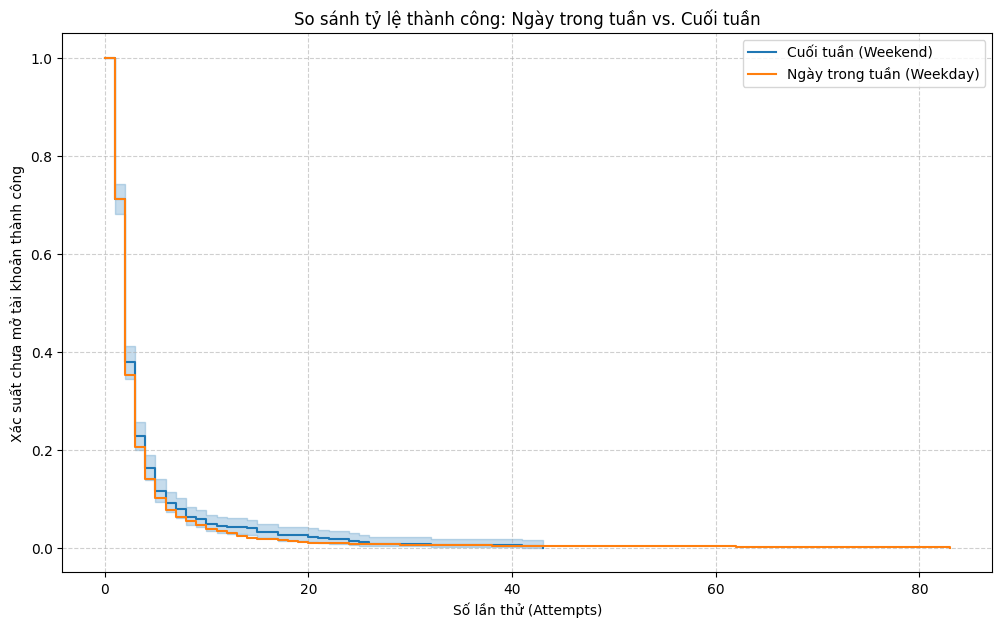


Kết quả kiểm định Log-Rank so sánh Ngày trong tuần và Cuối tuần:


<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic    p  -log2(p)
           2.86 0.09      3.46

In [ ]:
# --- 3. So sánh theo Ngày trong tuần vs. Cuối tuần ---
from lifelines.statistics import logrank_test

plt.figure(figsize=(12, 7))
ax = plt.subplot(111)

# Nhóm cuối tuần (is_weekend = 1)
weekend_mask = df_survival_time['is_weekend'] == 1
kmf.fit(T[weekend_mask], event_observed=E[weekend_mask], label='Cuối tuần (Weekend)')
kmf.plot_survival_function(ax=ax)
print("Đã vẽ xong cho nhóm Cuối tuần")

# Nhóm ngày trong tuần (is_weekend = 0)
weekday_mask = df_survival_time['is_weekend'] == 0
kmf.fit(T[weekday_mask], event_observed=E[weekday_mask], label='Ngày trong tuần (Weekday)')
kmf.plot_survival_function(ax=ax, ci_show=False)
print("Đã vẽ xong cho nhóm Ngày trong tuần")


plt.title('So sánh tỷ lệ thành công: Ngày trong tuần vs. Cuối tuần')
plt.xlabel('Số lần thử (Attempts)')
plt.ylabel('Xác suất chưa mở tài khoản thành công')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

# --- Kiểm định Log-Rank cho 2 nhóm ---
# Dùng logrank_test vì chỉ có 2 nhóm
results_weekend = logrank_test(
    T[weekend_mask],
    T[weekday_mask],
    event_observed_A=E[weekend_mask],
    event_observed_B=E[weekday_mask]
)

print("\nKết quả kiểm định Log-Rank so sánh Ngày trong tuần và Cuối tuần:")
results_weekend.print_summary()


Kết quả mô hình Cox Proportional Hazards:


<lifelines.CoxPHFitter: fitted with 9148 total observations, 605 right-censored observations>
             duration col = 'T'
                event col = 'E'
      baseline estimation = breslow
   number of observations = 9148
number of events observed = 8543
   partial log-likelihood = -69707.94
         time fit was run = 2025-06-19 02:20:07 UTC

---
                coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                       
age            -0.00      1.00      0.00           -0.01           -0.00                0.99                1.00
is_weekend      0.10      1.10      0.06           -0.02            0.22                0.98                1.24
is_office_hour  0.13      1.13      0.07           -0.01            0.26                0.99                1.29
gender_M        0.04      1.04      0.02           -0.01            0.08                0.99                1.08
phone_OPPO      0.09      1.09      0.09           -0.08            0.26                0.92                1.30
phone_Others   -0.29      0.75      0.07           -0.43           -0.15                0.65                0.86
phone_Redmi    -0.22      0.80      0.10           -0.41           -0.03                0.67                0.97
phone_samsung  -0.11      0.90      0.03           -0.18           -0.04                0.84                0.96
time_evening    0.26      1.30      0.07            0.13            0.40                1.14                1.49
time_morning    0.18      1.20      0.03            0.13            0.23                1.14                1.26

                cmp to     z      p  -log2(p)
covariate                                    
age               0.00 -2.13   0.03      4.92
is_weekend        0.00  1.64   0.10      3.32
is_office_hour    0.00  1.87   0.06      4.01
gender_M          0.00  1.65   0.10      3.35
phone_OPPO        0.00  1.03   0.30      1.72
phone_Others      0.00 -3.99 <0.005     13.90
phone_Redmi       0.00 -2.28   0.02      5.48
phone_samsung     0.00 -3.13 <0.005      9.16
time_evening      0.00  3.89 <0.005     13.30
time_morning      0.00  7.22 <0.005     40.76
---
Concordance = 0.55
Partial AIC = 139435.89
log-likelihood ratio test = 99.93 on 10 df
-log2(p) of ll-ratio test = 53.98

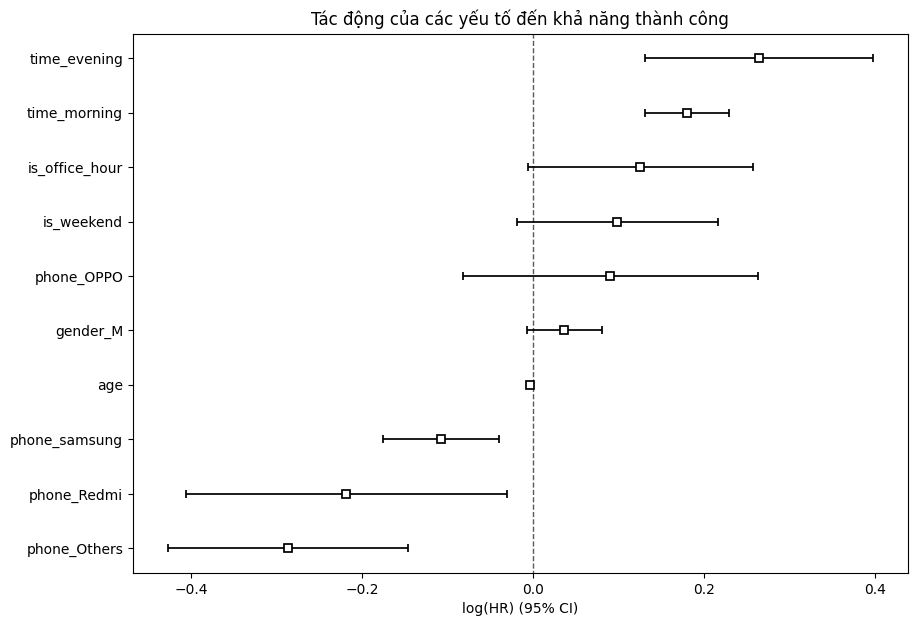

In [ ]:
# --- 4. Phân tích các yếu tố ảnh hưởng với mô hình CoxPH ---

# Khởi tạo mô hình
cph = CoxPHFitter()

# Fit mô hình vào dữ liệu. Mô hình sẽ tự động bỏ qua các cột không cần thiết.
cph.fit(df_survival, duration_col='T', event_col='E')

# In kết quả tóm tắt
print("\nKết quả mô hình Cox Proportional Hazards:")
cph.print_summary()

# Vẽ biểu đồ hệ số (để dễ hình dung)
plt.figure(figsize=(10, 7))
cph.plot()
plt.title('Tác động của các yếu tố đến khả năng thành công')
plt.show()